In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm

from stanza_tokenizer import StanzaTokenizer
from combine_chunks import consolidate_token_data

In [16]:
tokenizer = StanzaTokenizer()

2025-10-21 18:13:14 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-10-21 18:13:14 INFO: Downloaded file to /Users/stevie/stanza_resources/resources.json
2025-10-21 18:13:14 WARNING: Language it package default expects mwt, which has been added
2025-10-21 18:13:15 INFO: Loading these models for language: it (Italian):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2025-10-21 18:13:15 INFO: Using device: cpu
2025-10-21 18:13:15 INFO: Loading: tokenize
2025-10-21 18:13:15 INFO: Loading: mwt
2025-10-21 18:13:15 INFO: Loading: pos
2025-10-21 18:13:16 INFO: Loading: lemma
2025-10-21 18:13:16 INFO: Loading: depparse
2025-10-21 18:13:17 INFO: Done loading 

In [17]:
hp_path = '/Users/stevie/repos/lingo_kit_combined/lingo_kit_data/word_analysis/datasets/harry_potter/harry_potter_book_4_chapter_1_pages_15-23.txt'
text = open(hp_path).read()

In [18]:
hp_df = tokenizer.tokenize_to_df(text)
hp_df

,text,lemma,pos,xpos,head,deprel,feats,vector,token_hash,group_hash
0,capitolo,capitolo,NOUN,S,11,obl,Gender=Masc|Number=Sing,None,5c4fd2f4-05ae-555f-9ecb-020d6def9531,2dbe2631-6692-5a0c-a1d8-de2413a466b7
1,1,1,NUM,N,1,nummod,NumType=Card,None,81ee015e-1764-5eab-8332-5d4738f6aa64,a4fe73f3-8821-5b86-8305-2f1ef1fc997b
2,casa,casa,NOUN,S,1,nmod,Gender=Fem|Number=Sing,None,08caa1e2-a244-5002-8b4c-1e459877c7ee,1fcc7ef1-9863-5784-a176-93aa68f6a96c
3,riddle,riddle,PROPN,SP,3,nmod,None,None,d42bb050-684b-5fa8-9768-b35728df501c,84b4cdfd-aff7-5e38-b602-9a47d27a8f36
4,gli,il,DET,RD,6,det,Definite=Def|Gender=Masc|Number=Plur|PronType=Art,None,9ac39d22-f599-52d2-9387-74c8ded2b229,e5de14ca-b785-57e7-ae0b-4d8d72b47700
...,...,...,...,...,...,...,...,...,...,...
3694,in,in,ADP,E,19,case,None,None,fa2f7fd9-5908-59a0-89f9-a2967d8f26f6,8c1b2936-6ddd-507e-a1e5-832122e4b2c0
3695,locande,locanda,NOUN,S,9,obl,Gender=Fem|Number=Plur,None,75a970a9-7800-5f2a-98c3-cac352407932,453b25c8-2c22-58ab-8fc5-c430ba01e5b3
3696,lontane,lontano,ADJ,A,19,amod,Gender=Fem|Number=Plur,None,f77203ea-5f3e-5cdd-bb8e-9e7f23d543f0,922addb0-a399-5aba-9272-cad6b916f30b
3697,...,...,PUNCT,FS,5,punct,None,None,3428ea55-b176-5e49-a81e-d6a922d8c1ab,e299cc07-6e61-5d7a-a263-27b3f1f77313


In [19]:
def normalize(text):
    assert(text == text.lower())
    # text = text.lower()
    return text
def is_number(token):
    try:
        float(token)
        return True
    except ValueError:
        return False
print(len(hp_df))
hp_df = hp_df[~hp_df['text'].apply(is_number)]
print(len(hp_df))
hp_df['text'] = hp_df['text'].apply(normalize)
hp_df = hp_df[hp_df['pos'] != 'PUNCT']
print(len(hp_df))
hp_df.drop_duplicates(inplace=True)
print(len(hp_df))
hp_df = hp_df[hp_df['text'].str.contains('hangleton') == False]
print(len(hp_df))

3699
3698
3120
2512
2508


/var/folders/qs/n3mb_ckd47n6s9c65b_06xrw0000gn/T/ipykernel_37134/3226815064.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hp_df['text'] = hp_df['text'].apply(normalize)


In [20]:
print(len(hp_df))
hp_df = hp_df[hp_df['pos'] != 'PROPN']
print(len(hp_df))

2508
2384


In [21]:
# hp_df[hp_df.duplicated(subset=['text', 'pos'])].sort_values('text')
hp_df.drop_duplicates(subset=['text', 'lemma', 'pos'], inplace=True)
print(len(hp_df))

1136


In [ ]:
N = 44

n_sentence_list = []

found_tokens_list = []
missing_tokens_list = []
total_tokens_list = []

found_groups_list = []
missing_groups_list = []
total_groups_list = []

for chunks_i in range(1, N+1):
    print(f"Processing chunk size: {chunks_i * 10000}")
    # file_paths = []
    # for j in range(chunks_i):
    #     file_paths.append(f'new_token_data/token_data_chunk_{j}.tsv')
    # df = consolidate_token_data(file_paths)
    df = consolidate_token_data(chunks_i)

    missing_tokens = []
    found_tokens = []
    for _, row in hp_df.iterrows():
        token_match_df = df[df['token_hash'] == row['token_hash']]
        if len(token_match_df) == 0:
            missing_tokens.append((row['text'], row['lemma'], row['pos'], row['token_hash']))
        else:
            found_tokens.append((row['text'], row['lemma'], row['pos'], row['token_hash']))
    f = len(found_tokens)
    m = len(missing_tokens)
    total = f + m

    n_sentence_list.append(chunks_i * 10000)

    found_tokens_list.append(f)
    missing_tokens_list.append(m)
    total_tokens_list.append(total)

    found_groups = []
    missing_groups = []
    for group_hash in hp_df['group_hash'].unique():
        s_df = hp_df[hp_df['group_hash'] == group_hash]
        row = s_df.iloc[0]

        group_match_df = df[df['group_hash'] == group_hash]

        if len(group_match_df) == 0:
            missing_groups.append((row['lemma'], row['pos'], row['group_hash']))
        else:
            found_groups.append((row['lemma'], row['pos'], row['group_hash']))
    
    fg = len(found_groups)
    mg = len(missing_groups)
    totalg = fg + mg
    found_groups_list.append(fg)
    missing_groups_list.append(mg)
    total_groups_list.append(totalg)

Processing chunk size: 10000
Processing chunk size: 20000
Processing chunk size: 30000
Processing chunk size: 40000
Processing chunk size: 50000
Processing chunk size: 60000
Processing chunk size: 70000
Processing chunk size: 80000
Processing chunk size: 90000
Processing chunk size: 100000
Processing chunk size: 110000
Processing chunk size: 120000
Processing chunk size: 130000
Processing chunk size: 140000
Processing chunk size: 150000
Processing chunk size: 160000
Processing chunk size: 170000
Processing chunk size: 180000
Processing chunk size: 190000
Processing chunk size: 200000
Processing chunk size: 210000
Processing chunk size: 220000
Processing chunk size: 230000
Processing chunk size: 240000


100%|██████████| 17195/17195 [00:14<00:00, 1197.97it/s]


Processing chunk size: 250000


100%|██████████| 17432/17432 [00:14<00:00, 1179.95it/s]


Processing chunk size: 260000


100%|██████████| 17602/17602 [00:15<00:00, 1168.89it/s]


Processing chunk size: 270000


100%|██████████| 17742/17742 [00:15<00:00, 1151.95it/s]


Processing chunk size: 280000


100%|██████████| 17994/17994 [00:15<00:00, 1129.15it/s]


In [23]:
n_sentence_list = [i * 10000 for i in range(1, N+1)]

Fitted parameters: a=283.76832960431386, b=-1.9227295365028026e-05, c=183.16512663895796


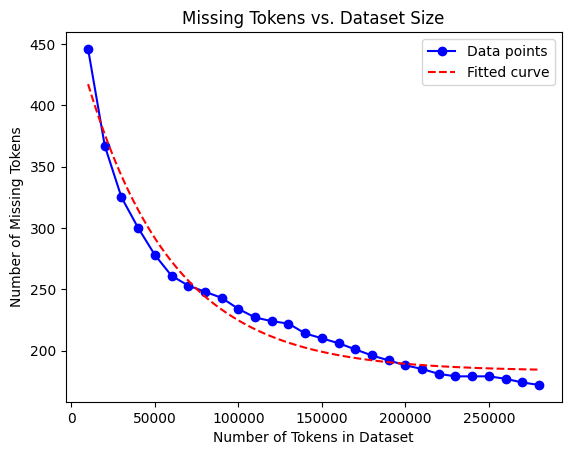

In [24]:
X = n_sentence_list
Y = missing_tokens_list
plt.plot(X, Y, 'bo-', label='Data points')
# let's fit a curve to this (looks like exponential decay)
def model(x, a, b, c):
    return a * np.exp(b * x) + c
popt, pcov = curve_fit(model, X, Y, p0=(400, -0.00001, 150), )
a, b, c = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}")
x_fit = np.linspace(min(X), max(X), 100)
y_fit = model(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Fitted curve')
plt.xlabel('Number of Tokens in Dataset')
plt.ylabel('Number of Missing Tokens')
plt.title('Missing Tokens vs. Dataset Size')
plt.legend()

Fitted parameters: a=197.2732032964095, b=-2.2467425819236497e-05, c=90.22701414517373


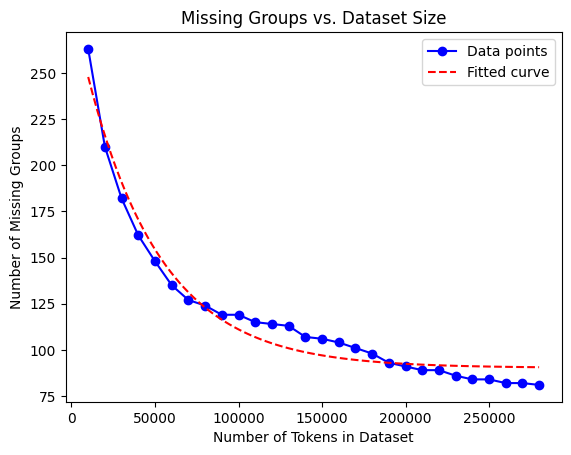

In [25]:
X = n_sentence_list
Y = missing_groups_list
plt.figure()
plt.plot(X, Y, 'bo-', label='Data points')
# let's fit a curve to this (looks like exponential decay)
def model(x, a, b, c):
    return a * np.exp(b * x) + c
popt, pcov = curve_fit(model, X, Y, p0=(300, -0.00001, 80))
a, b, c = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}")
x_fit = np.linspace(min(X), max(X), 100)
y_fit = model(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Fitted curve')
plt.xlabel('Number of Tokens in Dataset')
plt.ylabel('Number of Missing Groups')
plt.title('Missing Groups vs. Dataset Size')
plt.legend()

Fitted parameters: a=5841.365253590384, b=-0.27832666711423987, c=-5.199761124042528
Predicted missing tokens for dataset size 600000: 138.7797794392418


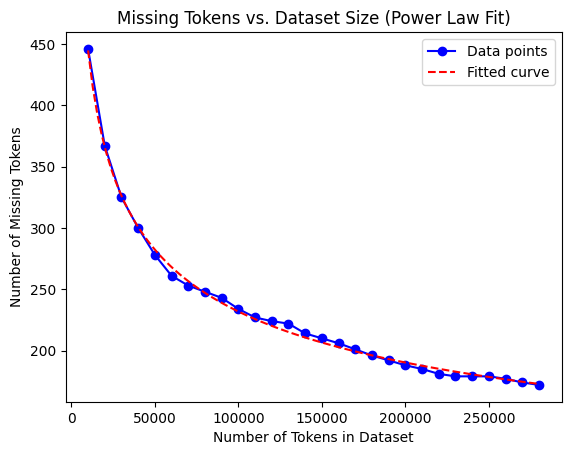

In [26]:
# instead of exponential, try power law
X = n_sentence_list
Y = missing_tokens_list
plt.figure()
plt.plot(X, Y, 'bo-', label='Data points')
# let's fit a curve to this (looks like power law)
def power_law(x, a, b, c):
    return a * np.power(x, b) + c
popt, pcov = curve_fit(power_law, X, Y, p0=(1e6, -1, 100))
a, b, c = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}")
x_fit = np.linspace(min(X), max(X), 100)
y_fit = power_law(x_fit, *popt)

test_x = 600000
test_y = power_law(test_x, *popt)
print(f"Predicted missing tokens for dataset size {test_x}: {test_y}")

plt.plot(x_fit, y_fit, 'r--', label='Fitted curve')
plt.xlabel('Number of Tokens in Dataset')
plt.ylabel('Number of Missing Tokens')
plt.title('Missing Tokens vs. Dataset Size (Power Law Fit)')
plt.legend()

# Predicted missing tokens for dataset size 600000: 139.58483964310713

Fitted parameters: a=6769.893943725418, b=-0.3525335101104629, c=0.6305719187040227


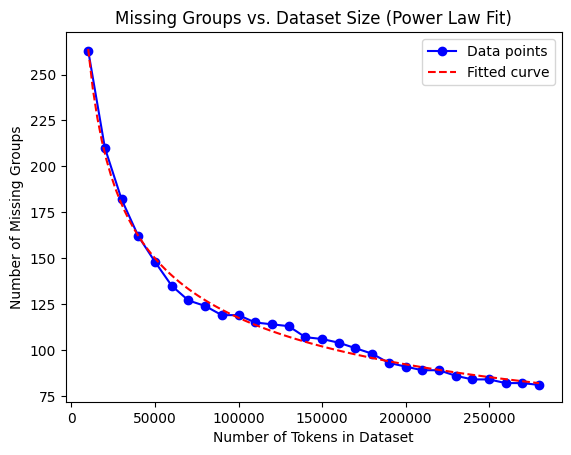

Predicted missing groups for dataset size 600000: 62.801868245829446


In [27]:
# instead of exponential, try power law
X = n_sentence_list
Y = missing_groups_list
plt.figure()
plt.plot(X, Y, 'bo-', label='Data points')
# let's fit a curve to this (looks like power law)
def power_law(x, a, b, c):
    return a * np.power(x, b) + c
popt, pcov = curve_fit(power_law, X, Y, p0=(1e5, -1, 50))
a, b, c = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}")
x_fit = np.linspace(min(X), max(X), 100)
y_fit = power_law(x_fit, *popt)
plt.plot(x_fit, y_fit, 'r--', label='Fitted curve')
plt.xlabel('Number of Tokens in Dataset')
plt.ylabel('Number of Missing Groups')
plt.title('Missing Groups vs. Dataset Size (Power Law Fit)')
plt.legend()
plt.show()
test_x = 600000
test_y = power_law(test_x, *popt)
print(f"Predicted missing groups for dataset size {test_x}: {test_y}")